In [1]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torch.nn import Threshold


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32) / 255.0
    return img

def GetSobelFeatures(img):
    # Compute x and y gradients using Sobel
    Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Gradient magnitude and orientation
    M = np.sqrt(Gx ** 2 + Gy ** 2)
    Theta = np.arctan2(Gy, Gx)  # in radians

    return Gx, Gy, M, Theta

def run_canny_batch(img, thresholds):
    edges = []
    for low, high in thresholds:
        edge = cv2.Canny(img, low, high)
        edges.append(edge)
    return edges

def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()


    plt.tight_layout()
    plt.show()

#This function is made by ChatGPT
def rotate_image(image, angle):
    height, width = image.shape[:2]
    center = (width/2, height/2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Scale to 0-255 for warpAffine
    rotated = cv2.warpAffine((image*255).astype(np.uint8), M, (width, height))

    # Convert back to 0-1 float if needed
    rotated = rotated.astype(np.float32) / 255.0

    return rotated

def normalize_for_display(result):
    norm = (result - np.min(result)) / (np.max(result) - np.min(result))
    return norm


ModuleNotFoundError: No module named 'torch'

0.999984860420227


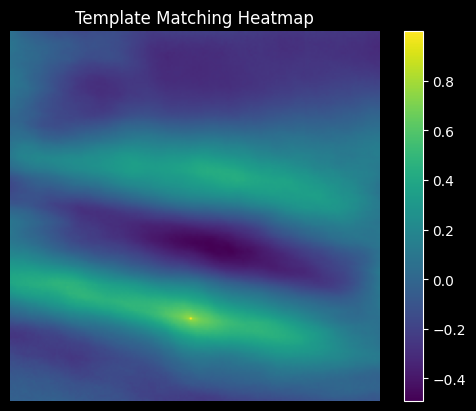

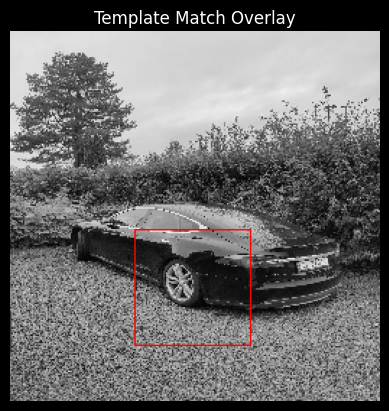

In [78]:
img = LoadImage('resized_256x256.jpg')
template = LoadImage('80x80_tire.jpg', size=(80,80))

# Match template
result = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)



h,w = template.shape

#max_val would be the brightest spot in the heatmap image, the "yellow dot"
#max_loc, would be the top left corner of the template image were the max_val is produced
#We can then draw a rectangle over the image based on the max_loc
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
overlay = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
cv2.rectangle(overlay, max_loc,(max_loc[0]+h,max_loc[1]+w), (0,0,255), 1)
print(max_val)


plt.imshow(result)
plt.colorbar()
plt.title("Template Matching Heatmap")
plt.axis("off")
plt.show()

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Template Match Overlay")
plt.axis("off")
plt.show()


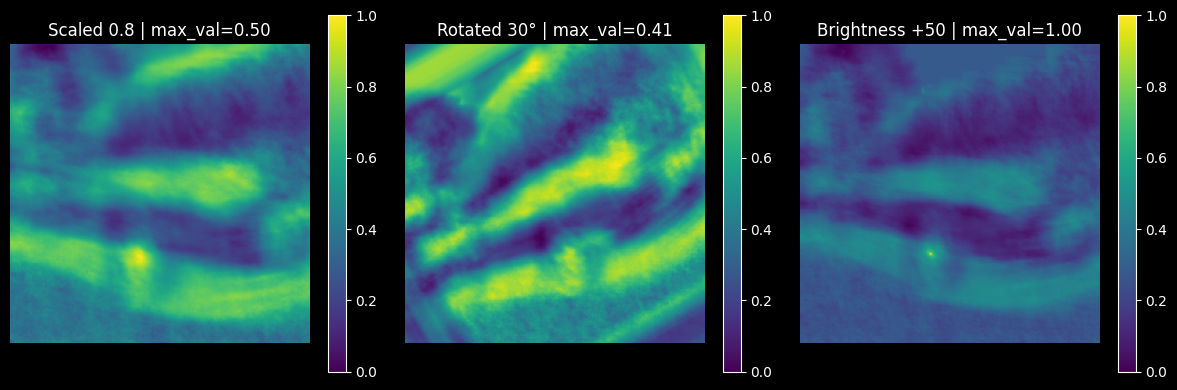

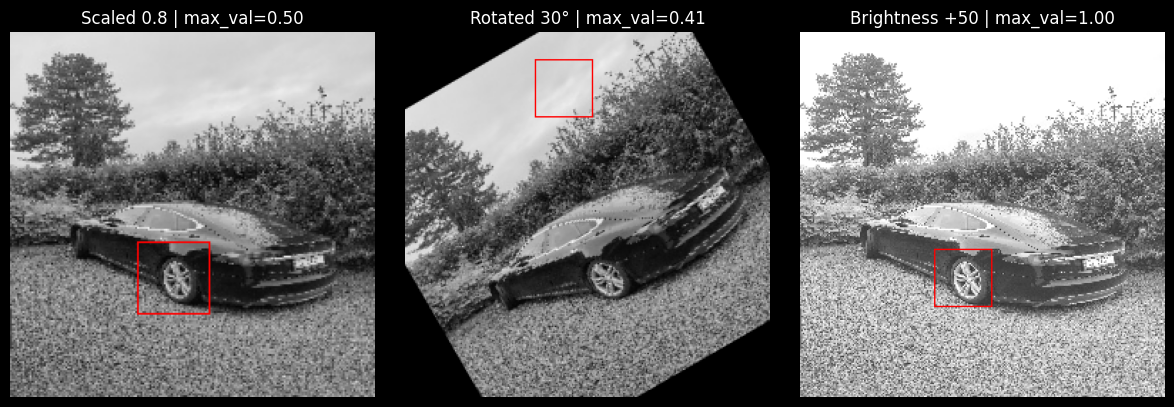

In [82]:
#Distort images
img1 = LoadImage('resized_256x256.jpg', size=(int(256*0.8), int(256*0.8)))
img2 = LoadImage('resized_256x256.jpg')
img2 = rotate_image(img2, 30)
img3 = LoadImage('resized_256x256.jpg')
img3 = (img3*255 + 50).clip(0,255).astype(np.float32) / 255.0

template = LoadImage('40x40_tire.jpg', size=(40,40))

# Match template
result1 = cv2.matchTemplate(img1, template, cv2.TM_CCOEFF_NORMED)
result2 = cv2.matchTemplate(img2, template, cv2.TM_CCOEFF_NORMED)
result3 = cv2.matchTemplate(img3, template, cv2.TM_CCOEFF_NORMED)

min_val1, max_val1, min_loc1, max_loc1 = cv2.minMaxLoc(result1)
min_val2, max_val2, min_loc2, max_loc2 = cv2.minMaxLoc(result2)
min_val3, max_val3, min_loc3, max_loc3 = cv2.minMaxLoc(result3)

h,w = template.shape

#Image
overlay1 = cv2.cvtColor((img1*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay2 = cv2.cvtColor((img2*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay3 = cv2.cvtColor((img3*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

#Rectangle overlay, based on location
cv2.rectangle(overlay1, max_loc1,(max_loc1[0]+h,max_loc1[1]+w), (255,0,0), 1)
cv2.rectangle(overlay2, max_loc2,(max_loc2[0]+h,max_loc2[1]+w), (255,0,0), 1)
cv2.rectangle(overlay3, max_loc3,(max_loc3[0]+h,max_loc3[1]+w), (255,0,0), 1)


# Normalize results for color display
result1_norm = normalize_for_display(result1)
result2_norm = normalize_for_display(result2)
result3_norm = normalize_for_display(result3)

# Titles with max_val
titles = [
    f"Scaled 0.8 | max_val={max_val1:.2f}",
    f"Rotated 30° | max_val={max_val2:.2f}",
    f"Brightness +50 | max_val={max_val3:.2f}"
]

# Display heatmaps with colormap
plot_images_grid([result1_norm, result2_norm, result3_norm], titles, cols=3, figsize=(12,4), heatmap=True)

# Display images with rectangles
plot_images_grid([overlay1, overlay2, overlay3], titles, cols=3, figsize=(12,4))

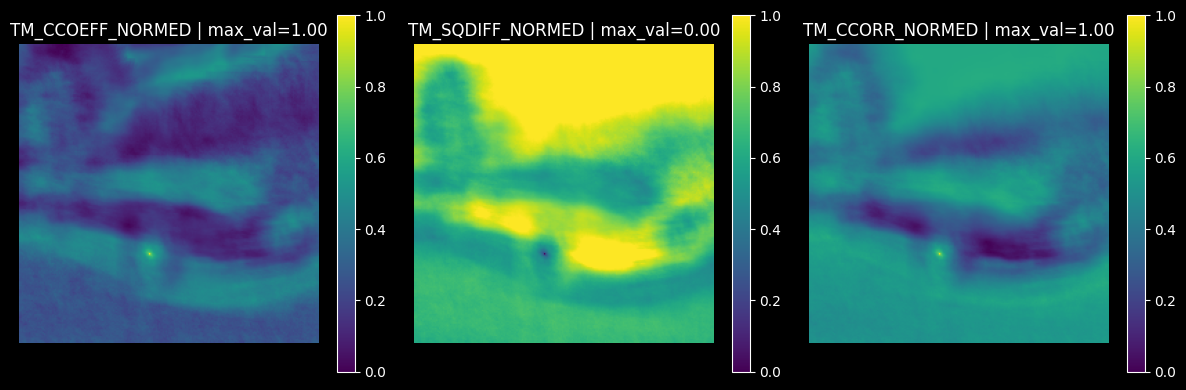

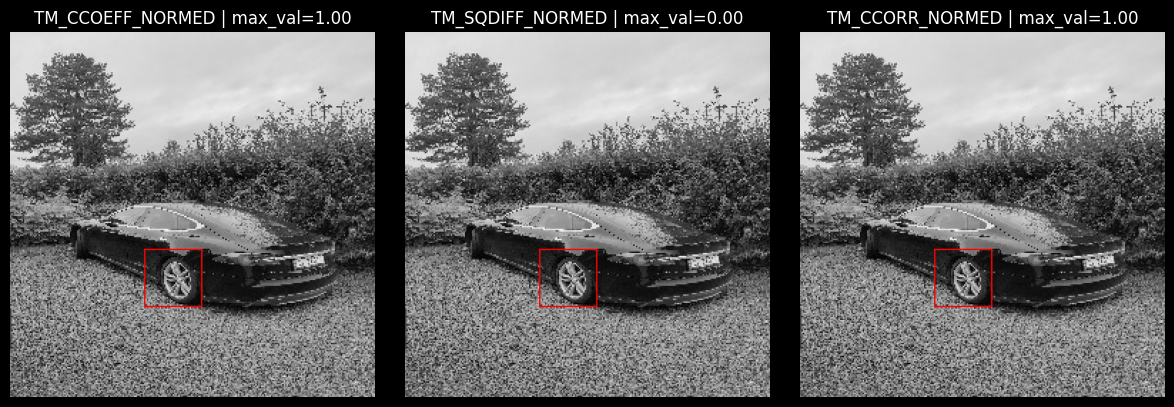

In [83]:
#Distort images
img1 = LoadImage('resized_256x256.jpg')
img2 = LoadImage('resized_256x256.jpg')
img3 = LoadImage('resized_256x256.jpg')



template = LoadImage('40x40_tire.jpg', size=(40,40))

# Match template
result1 = cv2.matchTemplate(img1, template, cv2.TM_CCOEFF_NORMED)
result2 = cv2.matchTemplate(img2, template, cv2.TM_SQDIFF_NORMED)
result3 = cv2.matchTemplate(img3, template, cv2.TM_CCORR_NORMED)

min_val1, max_val1, min_loc1, max_loc1 = cv2.minMaxLoc(result1)
min_val2, max_val2, min_loc2, max_loc2 = cv2.minMaxLoc(result2)
min_val3, max_val3, min_loc3, max_loc3 = cv2.minMaxLoc(result3)

h,w = template.shape

#Image
overlay1 = cv2.cvtColor((img1*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay2 = cv2.cvtColor((img2*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay3 = cv2.cvtColor((img3*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

#Rectangle overlay, based on location
cv2.rectangle(overlay1, max_loc1,(max_loc1[0]+h,max_loc1[1]+w), (255,0,0), 1)
cv2.rectangle(overlay2, min_loc2,(min_loc2[0]+h,min_loc2[1]+w), (255,0,0), 1)
cv2.rectangle(overlay3, max_loc3,(max_loc3[0]+h,max_loc3[1]+w), (255,0,0), 1)


# Normalize results for color display
result1_norm = normalize_for_display(result1)
result2_norm = normalize_for_display(result2)
result3_norm = normalize_for_display(result3)

# Titles with max_val
titles = [
    f"TM_CCOEFF_NORMED | max_val={max_val1:.2f}",
    f"TM_SQDIFF_NORMED | max_val={min_val2:.2f}",
    f"TM_CCORR_NORMED | max_val={max_val3:.2f}"
]

# Display heatmaps with colormap
plot_images_grid([result1_norm, result2_norm, result3_norm], titles, cols=3, figsize=(12,4), heatmap=True)

# Display images with rectangles
plot_images_grid([overlay1, overlay2, overlay3], titles, cols=3, figsize=(12,4))